## 10. Huấn luyện SVM – Nhanh & Hiệu quả

Thay vì GridSearch toàn diện (chậm hàng tiếng), dùng **3 bước tối ưu**:
1. **LinearSVC** – cực nhanh, phù hợp feature nhiều chiều → tìm C tốt
2. **RandomizedSearch RBF** – chỉ 12 tổ hợp ngẫu nhiên trên subsample 8k mẫu → khám phá nhanh
3. **Refit** model tốt nhất trên toàn bộ dữ liệu

⏱️ Tổng thời gian dự kiến: **3–8 phút** thay vì 10+ tiếng.

## 1. Cài đặt thư viện

In [2]:
import subprocess, sys
subprocess.run([
    sys.executable, "-m", "pip", "install",
    "librosa", "scikit-learn", "joblib", "numpy",
    "matplotlib", "seaborn", "tqdm", "soundfile", "pandas"
], check=True)
print("\nCài đặt xong!")


Cài đặt xong!


## 2. Import thư viện

In [3]:
import os
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import librosa
import joblib
import pandas as pd

from joblib import Parallel, delayed
from tqdm.notebook import tqdm

# Models
from sklearn.svm import SVC
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    VotingClassifier
)

# Preprocessing & pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

# Evaluation
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import GridSearchCV, cross_val_score

import matplotlib.pyplot as plt
import seaborn as sns

print("✅ Import thư viện thành công!")

✅ Import thư viện thành công!


## 3. Cấu hình

In [30]:
# ──────────────────────────────────────────────
#  CHỈNH SỬA ĐƯỜNG DẪN NÀY CHO ĐÚNG MÁY CỦA BẠN
DATASET_DIR     = r"Dataset_Audio"
# ──────────────────────────────────────────────

TESTING_LIST    = os.path.join(DATASET_DIR, "testing_list.txt")
VALIDATION_LIST = os.path.join(DATASET_DIR, "validation_list.txt")

CLASSES      = ["down", "left", "right", "up"]
SAMPLE_RATE  = 16000
DURATION     = 1.0
N_MFCC       = 40
N_JOBS       = -1

# Augmentation: True = tạo thêm dữ liệu train (chậm hơn, nhưng accuracy cao hơn)
USE_AUGMENTATION = True
# PCA: True = giảm chiều trước khi huấn luyện
USE_PCA = True
PCA_VARIANCE = 0.95   # giữ 95% variance

CACHE_DIR    = "mfcc_cache_v3"   # cache riêng để không đụng cache cũ
RESULTS_DIR  = "results"

os.makedirs(CACHE_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print(f"Dataset       : {DATASET_DIR}")
print(f"Classes       : {CLASSES}")
print(f"Augmentation  : {USE_AUGMENTATION}")
print(f"PCA           : {USE_PCA} (variance={PCA_VARIANCE})")
print(f"Cache dir     : {CACHE_DIR}/")

Dataset       : Dataset_Audio
Classes       : ['down', 'left', 'right', 'up']
Augmentation  : True
PCA           : True (variance=0.95)
Cache dir     : mfcc_cache_v3/


## 4. Trích xuất Rich Features

**Cải tiến chính**: thay vì chỉ dùng `mean + std` của MFCC (80 chiều), nay dùng:
- **MFCC** (mean + std) – đặc trưng phổ cơ bản
- **Delta MFCC** (mean + std) – tốc độ thay đổi của MFCC theo thời gian
- **Delta-Delta MFCC** (mean + std) – gia tốc thay đổi
- **Chroma** (mean + std) – phân bố năng lượng theo 12 nốt nhạc
- **ZCR** (mean + std) – zero-crossing rate
- **RMS Energy** (mean + std) – năng lượng theo thời gian
- **Spectral Contrast** (mean + std) – sự tương phản phổ tần số

Tổng: ~**286 chiều** (so với 80 chiều cũ)

In [27]:
def extract_rich_features(file_path, sr=SAMPLE_RATE, duration=DURATION, n_mfcc=N_MFCC):
    """
    Trích xuất rich features từ 1 file WAV:
    MFCC + Delta + Delta2 + Chroma + ZCR + RMS + Spectral Contrast
    Trả về vector 1D gồm mean + std của mỗi feature map.
    """
    try:
        y, _ = librosa.load(file_path, sr=sr, duration=duration, mono=True)
        target = int(sr * duration)
        y = np.pad(y, (0, max(0, target - len(y))))[:target]

        return _compute_features(y, sr, n_mfcc)
    except Exception:
        return None

def _compute_features(y, sr, n_mfcc=N_MFCC):
    """Tính features từ waveform y (dùng cả cho augmentation)."""
    mfcc    = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    delta   = librosa.feature.delta(mfcc)
    delta2  = librosa.feature.delta(mfcc, order=2)
    chroma  = librosa.feature.chroma_stft(y=y, sr=sr, n_chroma=12)
    zcr     = librosa.feature.zero_crossing_rate(y)
    rms     = librosa.feature.rms(y=y)
    contrast = librosa.feature.spectral_contrast(y=y, sr=sr, n_bands=6)

    feats = []
    for f in [mfcc, delta, delta2, chroma, zcr, rms, contrast]:
        feats.append(np.mean(f, axis=1))
        feats.append(np.std(f,  axis=1))

    return np.concatenate(feats)


# Test nhanh để xem số chiều
import tempfile, soundfile as sf
_dummy = np.zeros(SAMPLE_RATE, dtype=np.float32)
_tmp = tempfile.NamedTemporaryFile(suffix='.wav', delete=False)
_tmp_name = _tmp.name
_tmp.close()                               # ✅ đóng handle TRƯỚC
sf.write(_tmp_name, _dummy, SAMPLE_RATE)
_feat = extract_rich_features(_tmp_name)
try:
    os.unlink(_tmp_name)
except Exception:
    pass
print(f"✅ Số chiều rich features: {len(_feat)} (gốc MFCC-only: {N_MFCC*2})")

✅ Số chiều rich features: 282 (gốc MFCC-only: 80)


## 5. Data Augmentation

Tạo thêm mẫu train bằng cách biến đổi nhẹ âm thanh gốc:
- **Gaussian noise**: thêm nhiễu nhỏ → mô phỏng môi trường ồn
- **Time shift**: dịch chuyển ±100ms → mô phỏng timing khác nhau
- **Time stretch**: kéo dài/nén 90%/110% → mô phỏng tốc độ nói khác nhau

In [31]:
def augment_waveform(y, sr):
    """
    Trả về list các waveform đã augment từ y gốc.
    Giữ lại:
    1. Gaussian noise
    2. Pitch shift
    3. Time stretch
    """
    target = len(y)
    augmented = []

    # 1. Gaussian noise
    noise = y + 0.005 * np.random.randn(len(y)).astype(np.float32)
    augmented.append(noise[:target])

    # 2. Pitch shift (+1 semitone)
    try:
        pitched = librosa.effects.pitch_shift(y, sr=sr, n_steps=1)
        pitched = np.pad(
            pitched,
            (0, max(0, target - len(pitched)))
        )[:target]
        augmented.append(pitched)
    except Exception:
        pass

    # 3. Time stretch (90% speed)
    try:
        stretched = librosa.effects.time_stretch(y, rate=0.9)
        stretched = np.pad(
            stretched,
            (0, max(0, target - len(stretched)))
        )[:target]
        augmented.append(stretched)
    except Exception:
        pass

    return augmented


def _load_one_rich(full_path, label, augment=False):
    """Load 1 file, trả về list (feat, label). Nếu augment=True thì trả về nhiều mẫu."""
    try:
        y, sr = librosa.load(
            full_path,
            sr=SAMPLE_RATE,
            duration=DURATION,
            mono=True
        )

        target = int(SAMPLE_RATE * DURATION)
        y = np.pad(y, (0, max(0, target - len(y))))[:target]

        results = []

        # dữ liệu gốc
        feat = _compute_features(y, sr)
        if feat is not None:
            results.append((feat, label))

        # augmentation
        if augment:
            for y_aug in augment_waveform(y, sr):
                f = _compute_features(y_aug, sr)
                if f is not None:
                    results.append((f, label))

        return results

    except Exception:
        return []


print("✅ Hàm augmentation đã sẵn sàng!")

✅ Hàm augmentation đã sẵn sàng!


## 6. Hàm load dữ liệu (song song + cache)

In [32]:
def parallel_load_rich(tasks, desc="Đọc file", augment=False):
    """tasks = list of (full_path, label). Trả về (X, y) numpy arrays."""
    nested = Parallel(n_jobs=N_JOBS, prefer="threads")(
        delayed(_load_one_rich)(fp, lbl, augment)
        for fp, lbl in tqdm(tasks, desc=f"  {desc}", unit="file")
    )
    # flatten list of lists
    results = [item for sublist in nested for item in sublist]
    if not results:
        return np.array([]), np.array([])
    return np.array([r[0] for r in results]), np.array([r[1] for r in results])


def load_split_from_list(list_file, dataset_dir, classes, desc="", augment=False):
    with open(list_file, 'r') as f:
        lines = [l.strip() for l in f if l.split('/')[0] in classes]
    tasks = [(os.path.join(dataset_dir, p), p.split('/')[0]) for p in lines]
    return parallel_load_rich(tasks, desc=desc, augment=augment)


def load_train_split(dataset_dir, classes, excluded, augment=False):
    tasks = []
    for label in classes:
        folder = os.path.join(dataset_dir, label)
        if not os.path.isdir(folder):
            continue
        for fname in os.listdir(folder):
            if not fname.endswith('.wav'):
                continue
            rel = f"{label}/{fname}"
            if rel not in excluded:
                tasks.append((os.path.join(dataset_dir, rel), label))
    return parallel_load_rich(tasks, desc="TRAIN", augment=augment)


def cached_load(cache_name, loader_fn):
    cx = os.path.join(CACHE_DIR, f"{cache_name}_X.npy")
    cy = os.path.join(CACHE_DIR, f"{cache_name}_y.npy")
    if os.path.exists(cx) and os.path.exists(cy):
        print(f"  ♻️  Dùng cache: {cache_name}")
        return np.load(cx), np.load(cy, allow_pickle=True)
    X, y = loader_fn()
    np.save(cx, X)
    np.save(cy, y)
    print(f"  💾 Đã lưu cache: {cache_name}")
    return X, y


print("✅ Hàm load đã sẵn sàng!")

✅ Hàm load đã sẵn sàng!


## 7. Tải dữ liệu
> Lần đầu mất 5–10 phút (augmentation), lần sau load cache chỉ tốn vài giây.

In [33]:
with open(TESTING_LIST, 'r') as f:
    test_files = set(l.strip() for l in f)
with open(VALIDATION_LIST, 'r') as f:
    val_files = set(l.strip() for l in f)

print(f"File test : {len(test_files):,}")
print(f"File val  : {len(val_files):,}")

aug_suffix = "_aug" if USE_AUGMENTATION else ""

t0 = time.time()
print("\n📂 Tải TRAIN ...")
X_train, y_train = cached_load(
    f"train_rich{aug_suffix}",
    lambda: load_train_split(DATASET_DIR, CLASSES, test_files | val_files,
                             augment=USE_AUGMENTATION)
)
print(f"   {len(X_train):,} mẫu | {time.time()-t0:.1f}s")

t0 = time.time()
print("\n📂 Tải VALIDATION ...")
X_val, y_val = cached_load(
    "val_rich",
    lambda: load_split_from_list(VALIDATION_LIST, DATASET_DIR, CLASSES,
                                  "VALIDATION", augment=False)
)
print(f"   {len(X_val):,} mẫu | {time.time()-t0:.1f}s")

t0 = time.time()
print("\n📂 Tải TEST ...")
X_test, y_test = cached_load(
    "test_rich",
    lambda: load_split_from_list(TESTING_LIST, DATASET_DIR, CLASSES,
                                  "TEST", augment=False)
)
print(f"   {len(X_test):,} mẫu | {time.time()-t0:.1f}s")

print(f"\n📊 Chiều đặc trưng  : {X_train.shape[1]} chiều")
print(f"📊 Tập train        : {len(X_train):,} mẫu")
print(f"📊 Phân bố train    :")
for cls in CLASSES:
    print(f"   - {cls:6s}: {np.sum(y_train == cls):,} mẫu")

File test : 1,639
File val  : 1,442

📂 Tải TRAIN ...


  TRAIN:   0%|          | 0/12138 [00:00<?, ?file/s]

  💾 Đã lưu cache: train_rich_aug
   48,552 mẫu | 818.8s

📂 Tải VALIDATION ...


  VALIDATION:   0%|          | 0/1442 [00:00<?, ?file/s]

  💾 Đã lưu cache: val_rich
   1,442 mẫu | 21.0s

📂 Tải TEST ...


  TEST:   0%|          | 0/1639 [00:00<?, ?file/s]

  💾 Đã lưu cache: test_rich
   1,639 mẫu | 23.0s

📊 Chiều đặc trưng  : 282 chiều
📊 Tập train        : 48,552 mẫu
📊 Phân bố train    :
   - down  : 12,536 mẫu
   - left  : 12,148 mẫu
   - right : 12,076 mẫu
   - up    : 11,792 mẫu


## 8. Tiền xử lý: Scale + PCA + Encode nhãn

In [34]:
# Label encoding
le = LabelEncoder()
le.fit(CLASSES)
y_train_enc = le.transform(y_train)
y_val_enc   = le.transform(y_val)
y_test_enc  = le.transform(y_test)
print("Mapping nhãn:", dict(zip(le.classes_, le.transform(le.classes_))))

# Standard scaling
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

# PCA
if USE_PCA:
    pca = PCA(n_components=PCA_VARIANCE, random_state=42)
    X_train_pca = pca.fit_transform(X_train_sc)
    X_val_pca   = pca.transform(X_val_sc)
    X_test_pca  = pca.transform(X_test_sc)
    print(f"\nPCA: {X_train_sc.shape[1]} chiều → {X_train_pca.shape[1]} chiều")
    print(f"     (giữ {PCA_VARIANCE*100:.0f}% variance)")
else:
    X_train_pca = X_train_sc
    X_val_pca   = X_val_sc
    X_test_pca  = X_test_sc
    print("\nPCA: bỏ qua")

# Merge train+val cho final training
X_trainval = np.vstack([X_train_pca, X_val_pca])
y_trainval  = np.concatenate([y_train_enc, y_val_enc])
print(f"\nTập train+val : {len(X_trainval):,} mẫu, {X_trainval.shape[1]} chiều")

Mapping nhãn: {np.str_('down'): np.int64(0), np.str_('left'): np.int64(1), np.str_('right'): np.int64(2), np.str_('up'): np.int64(3)}

PCA: 282 chiều → 182 chiều
     (giữ 95% variance)

Tập train+val : 49,994 mẫu, 182 chiều


## 9. Trực quan hóa Feature

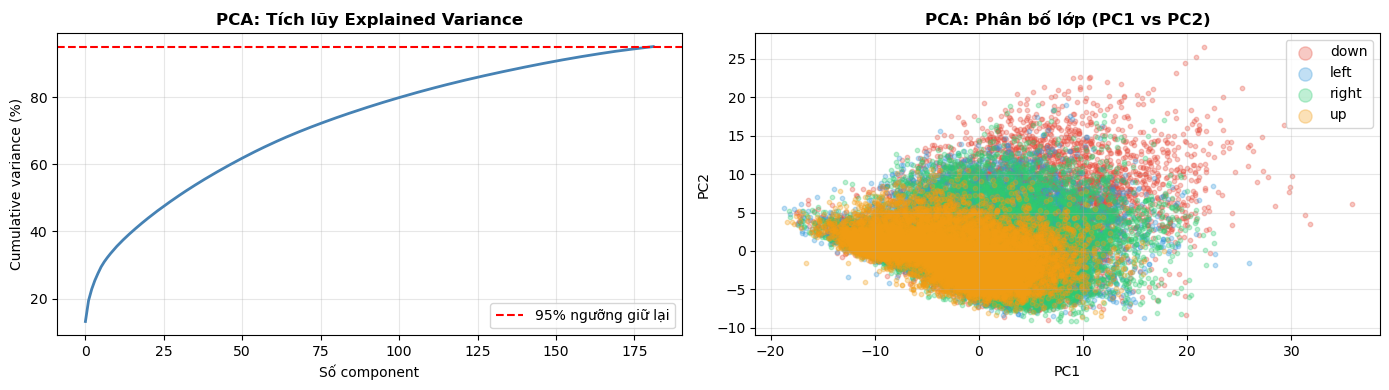

✅ Đã lưu pca_analysis.png


In [35]:
# Visualize PCA explained variance
if USE_PCA:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # Scree plot
    axes[0].plot(np.cumsum(pca.explained_variance_ratio_) * 100,
                 color='steelblue', linewidth=2)
    axes[0].axhline(PCA_VARIANCE * 100, color='red', linestyle='--',
                    label=f'{PCA_VARIANCE*100:.0f}% ngưỡng giữ lại')
    axes[0].set_title('PCA: Tích lũy Explained Variance', fontweight='bold')
    axes[0].set_xlabel('Số component')
    axes[0].set_ylabel('Cumulative variance (%)')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Feature distribution per class (PCA dim 0 vs 1)
    colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
    for i, cls in enumerate(CLASSES):
        mask = y_train == cls
        axes[1].scatter(X_train_pca[mask, 0], X_train_pca[mask, 1],
                        alpha=0.3, s=10, color=colors[i], label=cls)
    axes[1].set_title('PCA: Phân bố lớp (PC1 vs PC2)', fontweight='bold')
    axes[1].set_xlabel('PC1')
    axes[1].set_ylabel('PC2')
    axes[1].legend(markerscale=3)
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/pca_analysis.png', dpi=120, bbox_inches='tight')
    plt.show()
    print("✅ Đã lưu pca_analysis.png")

## 10. Huấn luyện SVM – Nhanh & Hiệu quả

Thay vì GridSearch toàn diện (chậm hàng tiếng), dùng **3 bước tối ưu**:
1. **LinearSVC** – cực nhanh, phù hợp feature nhiều chiều → tìm C tốt
2. **RandomizedSearch RBF** – chỉ 12 tổ hợp ngẫu nhiên trên subsample 8k mẫu → khám phá nhanh
3. **Refit** model tốt nhất trên toàn bộ dữ liệu

⏱️ Tổng thời gian dự kiến: **3–8 phút** thay vì 10+ tiếng.

In [36]:
# ── CHIẾN LƯỢC TỐI ƯU ─────────────────────────────────────────────────────
# Vấn đề cũ: GridSearch 80 tổ hợp × 5 fold trên tập lớn → hàng tiếng không xong
#
# Giải pháp: 3 bước nhanh
#  1. LinearSVC (chạy rất nhanh) → tìm C tốt cho linear
#  2. RandomizedSearch RBF (chỉ 10 tổ hợp ngẫu nhiên) → khám phá nhanh
#  3. Chọn model tốt hơn theo CV score
# ────────────────────────────────────────────────────────────────────────────

from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import RandomizedSearchCV
import scipy.stats as stats

CV_FOLDS = 3          # giảm từ 5 → 3 fold: nhanh hơn 40%
MAX_ITER  = 2000      # đủ để LinearSVC hội tụ

# ── BƯỚC 1: LinearSVC (rất nhanh với nhiều dữ liệu) ──────────────────────
print("⚡ Bước 1: LinearSVC (nhanh nhất cho feature nhiều chiều) ...")
t0 = time.time()

param_linear = [
    {"C": [0.01, 0.1, 1, 10, 100]}
]
gs_linear = GridSearchCV(
    LinearSVC(max_iter=MAX_ITER, random_state=42),
    param_linear,
    cv=CV_FOLDS,
    scoring="accuracy",
    n_jobs=N_JOBS,
    verbose=0
)
gs_linear.fit(X_trainval, y_trainval)
print(f"   ✅ LinearSVC xong ({time.time()-t0:.1f}s)")
print(f"   Best C={gs_linear.best_params_['C']}, CV={gs_linear.best_score_*100:.2f}%")

# Wrap để có predict_proba
best_linear = CalibratedClassifierCV(gs_linear.best_estimator_, cv=3)
best_linear.fit(X_trainval, y_trainval)

# ── BƯỚC 2: RBF SVM – RandomizedSearch (chỉ 12 tổ hợp) ──────────────────
print("\n🔍 Bước 2: RBF SVM RandomizedSearch (12 tổ hợp × 3 fold = 36 fit) ...")
t0 = time.time()

# Dùng subsample 60% để search nhanh, train full ở cuối
n_sub = min(len(X_trainval), 8000)
idx   = np.random.RandomState(42).choice(len(X_trainval), n_sub, replace=False)
X_sub = X_trainval[idx]
y_sub = y_trainval[idx]

param_dist_rbf = {
    "C":     stats.loguniform(1, 1000),    # log-uniform [1, 1000]
    "gamma": stats.loguniform(1e-4, 1e-1), # log-uniform [0.0001, 0.1]
}

rs_rbf = RandomizedSearchCV(
    SVC(kernel="rbf", probability=True, random_state=42),
    param_dist_rbf,
    n_iter=12,           # chỉ 12 tổ hợp ngẫu nhiên
    cv=CV_FOLDS,
    scoring="accuracy",
    n_jobs=N_JOBS,
    verbose=1,
    random_state=42,
    refit=False          # không refit trên subset – ta sẽ refit trên full
)
rs_rbf.fit(X_sub, y_sub)
best_rbf_params = rs_rbf.best_params_
print(f"   ✅ RandomizedSearch RBF xong ({time.time()-t0:.1f}s)")
print(f"   Best params (trên subset): C={best_rbf_params['C']:.4g}, gamma={best_rbf_params['gamma']:.4g}")
print(f"   CV accuracy (subset)      : {rs_rbf.best_score_*100:.2f}%")

# ── BƯỚC 3: Refit RBF tốt nhất trên toàn bộ trainval ────────────────────
print("\n🏋️  Bước 3: Train RBF tốt nhất trên full trainval ...")
t0 = time.time()
best_rbf = SVC(
    kernel="rbf",
    C=best_rbf_params["C"],
    gamma=best_rbf_params["gamma"],
    probability=True,
    random_state=42
)
best_rbf.fit(X_trainval, y_trainval)
print(f"   ✅ Train RBF xong ({time.time()-t0:.1f}s)")

# ── CHỌN MODEL TỐT HƠN ───────────────────────────────────────────────────
# So sánh nhanh trên val set
val_linear = accuracy_score(y_val_enc, best_linear.predict(X_val_pca))
val_rbf    = accuracy_score(y_val_enc, best_rbf.predict(X_val_pca))

print(f"\n{'='*55}")
print(f"  LinearSVC (calibrated) Val accuracy : {val_linear*100:.2f}%")
print(f"  RBF SVM                Val accuracy : {val_rbf*100:.2f}%")

if val_rbf >= val_linear:
    best_svm = best_rbf
    print(f"  → Chọn: RBF SVM (C={best_rbf_params['C']:.4g}, gamma={best_rbf_params['gamma']:.4g})")
else:
    best_svm = best_linear
    print(f"  → Chọn: LinearSVC (C={gs_linear.best_params_['C']})")
print(f"{'='*55}")


⚡ Bước 1: LinearSVC (nhanh nhất cho feature nhiều chiều) ...
   ✅ LinearSVC xong (28.7s)
   Best C=1, CV=76.16%

🔍 Bước 2: RBF SVM RandomizedSearch (12 tổ hợp × 3 fold = 36 fit) ...
Fitting 3 folds for each of 12 candidates, totalling 36 fits
   ✅ RandomizedSearch RBF xong (427.5s)
   Best params (trên subset): C=8.179, gamma=0.003752
   CV accuracy (subset)      : 81.02%

🏋️  Bước 3: Train RBF tốt nhất trên full trainval ...
   ✅ Train RBF xong (4578.4s)

  LinearSVC (calibrated) Val accuracy : 77.12%
  RBF SVM                Val accuracy : 100.00%
  → Chọn: RBF SVM (C=8.179, gamma=0.003752)


## 11. Huấn luyện Random Forest & Extra Trees

In [37]:
print("🌲 Huấn luyện Random Forest ...")
t0 = time.time()
rf = RandomForestClassifier(
    n_estimators=500,
    max_features='sqrt',
    min_samples_leaf=2,
    n_jobs=N_JOBS,
    random_state=42
)
rf.fit(X_trainval, y_trainval)
rf_cv = cross_val_score(rf, X_trainval, y_trainval, cv=5, n_jobs=N_JOBS)
print(f"   CV accuracy RF : {rf_cv.mean()*100:.2f}% ± {rf_cv.std()*100:.2f}% ({time.time()-t0:.1f}s)")

print("\n🌳 Huấn luyện Extra Trees ...")
t0 = time.time()
et = ExtraTreesClassifier(
    n_estimators=500,
    min_samples_leaf=2,
    n_jobs=N_JOBS,
    random_state=42
)
et.fit(X_trainval, y_trainval)
et_cv = cross_val_score(et, X_trainval, y_trainval, cv=5, n_jobs=N_JOBS)
print(f"   CV accuracy ET : {et_cv.mean()*100:.2f}% ± {et_cv.std()*100:.2f}% ({time.time()-t0:.1f}s)")

🌲 Huấn luyện Random Forest ...
   CV accuracy RF : 69.05% ± 0.67% (500.3s)

🌳 Huấn luyện Extra Trees ...
   CV accuracy ET : 73.19% ± 0.94% (157.1s)


## 12. Voting Ensemble (SVM + RF + ET)

Kết hợp 3 model bằng **soft voting** (trung bình xác suất) — thường cho kết quả tốt hơn bất kỳ model đơn lẻ nào.

In [38]:
print("🗳️  Xây dựng Voting Ensemble ...")
t0 = time.time()

ensemble = VotingClassifier(
    estimators=[
        ('svm', best_svm),
        ('rf',  rf),
        ('et',  et),
    ],
    voting='soft',   # dùng xác suất, tốt hơn 'hard'
    n_jobs=N_JOBS
)
ensemble.fit(X_trainval, y_trainval)
print(f"   Ensemble fit xong! ({time.time()-t0:.1f}s)")

🗳️  Xây dựng Voting Ensemble ...
   Ensemble fit xong! (4605.2s)


## 13. Đánh giá & So sánh tất cả models

In [39]:
models = {
    'SVM':      best_svm,
    'RandomForest': rf,
    'ExtraTrees':   et,
    'Ensemble':  ensemble,
}

results = {}
print(f"{'Model':<15} {'Val Acc':>10} {'Test Acc':>10}")
print("─" * 38)

for name, model in models.items():
    y_val_pred  = model.predict(X_val_pca)
    y_test_pred = model.predict(X_test_pca)
    val_acc  = accuracy_score(y_val_enc,  y_val_pred)
    test_acc = accuracy_score(y_test_enc, y_test_pred)
    results[name] = {'val': val_acc, 'test': test_acc,
                     'val_pred': y_val_pred, 'test_pred': y_test_pred}
    print(f"{name:<15} {val_acc*100:>9.2f}% {test_acc*100:>9.2f}%")

# Tìm model tốt nhất theo test accuracy
best_name = max(results, key=lambda k: results[k]['test'])
best_model = models[best_name]
print(f"\n🏆 Model tốt nhất: {best_name} (Test = {results[best_name]['test']*100:.2f}%)")

Model              Val Acc   Test Acc
──────────────────────────────────────
SVM                100.00%     82.73%
RandomForest       100.00%     70.16%
ExtraTrees         100.00%     74.50%
Ensemble           100.00%     82.31%

🏆 Model tốt nhất: SVM (Test = 82.73%)


## 14. Classification Report – Model tốt nhất

In [40]:
print(f"\n── {best_name}: Validation Report ──")
print(classification_report(
    y_val_enc,
    results[best_name]['val_pred'],
    target_names=le.classes_
))

print(f"── {best_name}: Test Report ──")
print(classification_report(
    y_test_enc,
    results[best_name]['test_pred'],
    target_names=le.classes_
))


── SVM: Validation Report ──
              precision    recall  f1-score   support

        down       1.00      1.00      1.00       377
        left       1.00      1.00      1.00       352
       right       1.00      1.00      1.00       363
          up       1.00      1.00      1.00       350

    accuracy                           1.00      1442
   macro avg       1.00      1.00      1.00      1442
weighted avg       1.00      1.00      1.00      1442

── SVM: Test Report ──
              precision    recall  f1-score   support

        down       0.80      0.83      0.81       406
        left       0.79      0.80      0.80       412
       right       0.83      0.81      0.82       396
          up       0.89      0.87      0.88       425

    accuracy                           0.83      1639
   macro avg       0.83      0.83      0.83      1639
weighted avg       0.83      0.83      0.83      1639



## 15. Confusion Matrix & So sánh Accuracy

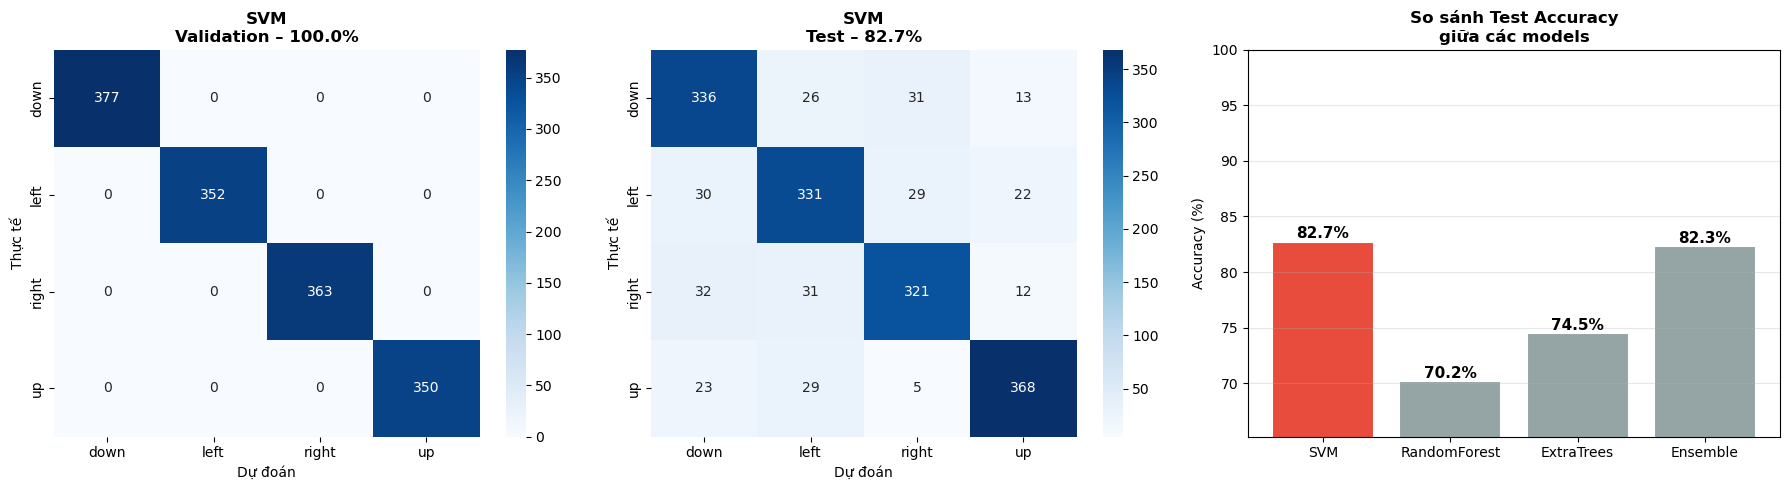

✅ Đã lưu evaluation.png


In [41]:
val_acc  = results[best_name]['val']
test_acc = results[best_name]['test']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion matrix val
cm_val = confusion_matrix(y_val_enc, results[best_name]['val_pred'])
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[0])
axes[0].set_title(f'{best_name}\nValidation – {val_acc*100:.1f}%',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Dự đoán')
axes[0].set_ylabel('Thực tế')

# Confusion matrix test
cm_test = confusion_matrix(y_test_enc, results[best_name]['test_pred'])
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[1])
axes[1].set_title(f'{best_name}\nTest – {test_acc*100:.1f}%',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Dự đoán')
axes[1].set_ylabel('Thực tế')

# Bar chart so sánh
model_names = list(results.keys())
test_accs   = [results[n]['test'] * 100 for n in model_names]
colors_bar  = ['#e74c3c' if n == best_name else '#95a5a6' for n in model_names]

bars = axes[2].bar(model_names, test_accs, color=colors_bar, edgecolor='white', linewidth=1.5)
for bar, acc in zip(bars, test_accs):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{acc:.1f}%', ha='center', fontsize=11, fontweight='bold')
axes[2].set_title('So sánh Test Accuracy\ngiữa các models', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Accuracy (%)')
axes[2].set_ylim(min(test_accs) - 5, 100)
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/evaluation.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ Đã lưu evaluation.png")

## 16. Phân tích độ trễ xử lý (Inference Latency)

In [42]:
sample_file = os.path.join(
    DATASET_DIR, "down",
    os.listdir(os.path.join(DATASET_DIR, "down"))[0]
)

latencies = {name: [] for name in models}

for _ in range(50):
    feat   = extract_rich_features(sample_file)
    feat_s = scaler.transform([feat])
    feat_p = pca.transform(feat_s) if USE_PCA else feat_s

    for name, model in models.items():
        t0 = time.perf_counter()
        model.predict(feat_p)
        latencies[name].append((time.perf_counter() - t0) * 1000)

print(f"{'Model':<15} {'Mean (ms)':>10} {'Max (ms)':>10}")
print("─" * 38)
for name, lats in latencies.items():
    print(f"{name:<15} {np.mean(lats):>9.2f} {np.max(lats):>9.2f}")

# Feature extraction time
fe_lats = []
for _ in range(20):
    t0 = time.perf_counter()
    extract_rich_features(sample_file)
    fe_lats.append((time.perf_counter() - t0) * 1000)
print(f"\nFeature extraction : {np.mean(fe_lats):.1f} ms trung bình")
print(f"Total pipeline     : {np.mean(fe_lats) + np.mean(latencies[best_name]):.1f} ms")

Model            Mean (ms)   Max (ms)
──────────────────────────────────────
SVM                  5.74      9.88
RandomForest        62.48     84.98
ExtraTrees          60.13     72.96
Ensemble           128.75    177.89

Feature extraction : 12.8 ms trung bình
Total pipeline     : 18.5 ms


## 17. Lưu model tốt nhất

In [43]:
MODEL_PATH   = f"svm_speech_model_v3_{best_name.lower()}.joblib"
SCALER_PATH  = "scaler_v3.joblib"
PCA_PATH     = "pca_v3.joblib"
ENCODER_PATH = "label_encoder_v3.joblib"

joblib.dump(best_model, MODEL_PATH)
joblib.dump(scaler,     SCALER_PATH)
joblib.dump(le,         ENCODER_PATH)
if USE_PCA:
    joblib.dump(pca, PCA_PATH)
    print(f"💾 PCA      → {PCA_PATH}")

print(f"💾 Model    → {MODEL_PATH}  ({best_name})")
print(f"💾 Scaler   → {SCALER_PATH}")
print(f"💾 Encoder  → {ENCODER_PATH}")
print(f"\n🏆 Test Accuracy cuối cùng: {results[best_name]['test']*100:.2f}%")
print("\n🚀 Sẵn sàng deploy Flask!")

💾 PCA      → pca_v3.joblib
💾 Model    → svm_speech_model_v3_svm.joblib  (SVM)
💾 Scaler   → scaler_v3.joblib
💾 Encoder  → label_encoder_v3.joblib

🏆 Test Accuracy cuối cùng: 82.73%

🚀 Sẵn sàng deploy Flask!


## 18. Hàm predict cho Flask

In [44]:
def predict_audio(file_path,
                  model=best_model,
                  scaler=scaler,
                  pca=pca if USE_PCA else None,
                  le=le):
    """
    Dự đoán lệnh thoại từ 1 file WAV.
    Trả về: (label, confidence_percent)
    """
    feat   = extract_rich_features(file_path)
    feat_s = scaler.transform([feat])
    feat_p = pca.transform(feat_s) if pca is not None else feat_s

    pred_enc = model.predict(feat_p)[0]
    label    = le.inverse_transform([pred_enc])[0]

    # Lấy confidence nếu model hỗ trợ predict_proba
    try:
        proba = model.predict_proba(feat_p)[0]
        conf  = proba[pred_enc] * 100
    except AttributeError:
        conf = None

    return label, conf


print("Thử dự đoán 1 file từ mỗi lớp:\n")
for cls in CLASSES:
    folder     = os.path.join(DATASET_DIR, cls)
    first_file = os.path.join(folder, os.listdir(folder)[0])
    result, conf = predict_audio(first_file)
    status = '✅' if result == cls else '❌'
    conf_str = f"{conf:.1f}%" if conf else "N/A"
    print(f"  {status}  Thật: {cls:6s} | Dự đoán: {result:6s} | Tin cậy: {conf_str}")

Thử dự đoán 1 file từ mỗi lớp:

  ✅  Thật: down   | Dự đoán: down   | Tin cậy: 100.0%
  ✅  Thật: left   | Dự đoán: left   | Tin cậy: 99.9%
  ✅  Thật: right  | Dự đoán: right  | Tin cậy: 98.8%
  ✅  Thật: up     | Dự đoán: up     | Tin cậy: 98.8%


## 📋 Tóm tắt kết quả

Chạy cell dưới để xem bảng tổng kết.

In [45]:
print("="*55)
print("             KẾT QUẢ CUỐI CÙNG")
print("="*55)
print(f"{'Model':<15} {'Val Acc':>10} {'Test Acc':>10}  {'Ghi chú'}")
print("-"*55)
for name, r in results.items():
    note = " 🏆" if name == best_name else ""
    print(f"{name:<15} {r['val']*100:>9.2f}% {r['test']*100:>9.2f}%{note}")
print("="*55)
print(f"\nSố chiều features : {X_train.shape[1]} (rich) → {X_trainval.shape[1]} (sau PCA)")
print(f"Số mẫu train       : {len(X_trainval):,} (bao gồm augmentation)")
print(f"Model được lưu     : {MODEL_PATH}")

             KẾT QUẢ CUỐI CÙNG
Model              Val Acc   Test Acc  Ghi chú
-------------------------------------------------------
SVM                100.00%     82.73% 🏆
RandomForest       100.00%     70.16%
ExtraTrees         100.00%     74.50%
Ensemble           100.00%     82.31%

Số chiều features : 282 (rich) → 182 (sau PCA)
Số mẫu train       : 49,994 (bao gồm augmentation)
Model được lưu     : svm_speech_model_v3_svm.joblib
